# Exemplo de rede bayesiana

In [13]:
import networkx as nx
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import numpy as np
import pandas as pd
from parepy_toolbox import random_sampling
import matplotlib.pyplot as plt
import itertools


## Exemplo

In [14]:

data = {
    "Code": ["A", "B", "C", "D"],
    "Task Name": [
        "Activity 1",
        "Activity 2",
        "Activity 3",
        "Activity 4"
    ],
    "Predecessors": [
        None,
        "A",
        "A",
        "B,C"
    ],
    "Min": [0.50, 2.00, 3.00,  1.80],
    "Mode": [1.00, 3.00, 4.00,2.00],
    "Max": [2.00, 4.00, 5.00, 4.00]
}

df = pd.DataFrame(data)

print(df)


  Code   Task Name Predecessors  Min  Mode  Max
0    A  Activity 1         None  0.5   1.0  2.0
1    B  Activity 2            A  2.0   3.0  4.0
2    C  Activity 3            A  3.0   4.0  5.0
3    D  Activity 4          B,C  1.8   2.0  4.0


### Gerar amostras

In [15]:
samples = {}
params = {}
# Calculate for triangular distribution

params = {
    row["Code"]: {
        "min": float(row["Min"]),
        "mode": float(row["Mode"]),
        "max": float(row["Max"]),
    }
    for _, row in df.iterrows()
}

# Generate samples
for k, p in params.items():
    samples[k] = random_sampling(
        dist="triangular",
        parameters=p,
        method='lhs',
        n_samples=10000
    )

# Convert samples to DataFrame
amostras = pd.DataFrame(samples)
amostras

,A,B,C,D
0,1.583664,2.941337,3.511308,2.878294
1,1.015402,2.818354,3.845855,2.105205
2,1.151660,2.795044,4.267079,2.835748
3,0.927291,2.782566,4.062067,3.116488
4,0.911077,3.008438,4.295299,2.005643
...,...,...,...,...
9995,0.788539,2.858196,4.746068,3.036398
9996,1.118586,3.034495,3.962266,2.341428
9997,1.970649,2.199845,3.871632,2.324449
9998,0.946102,2.682292,3.722097,2.440974


### Plotar histogramas

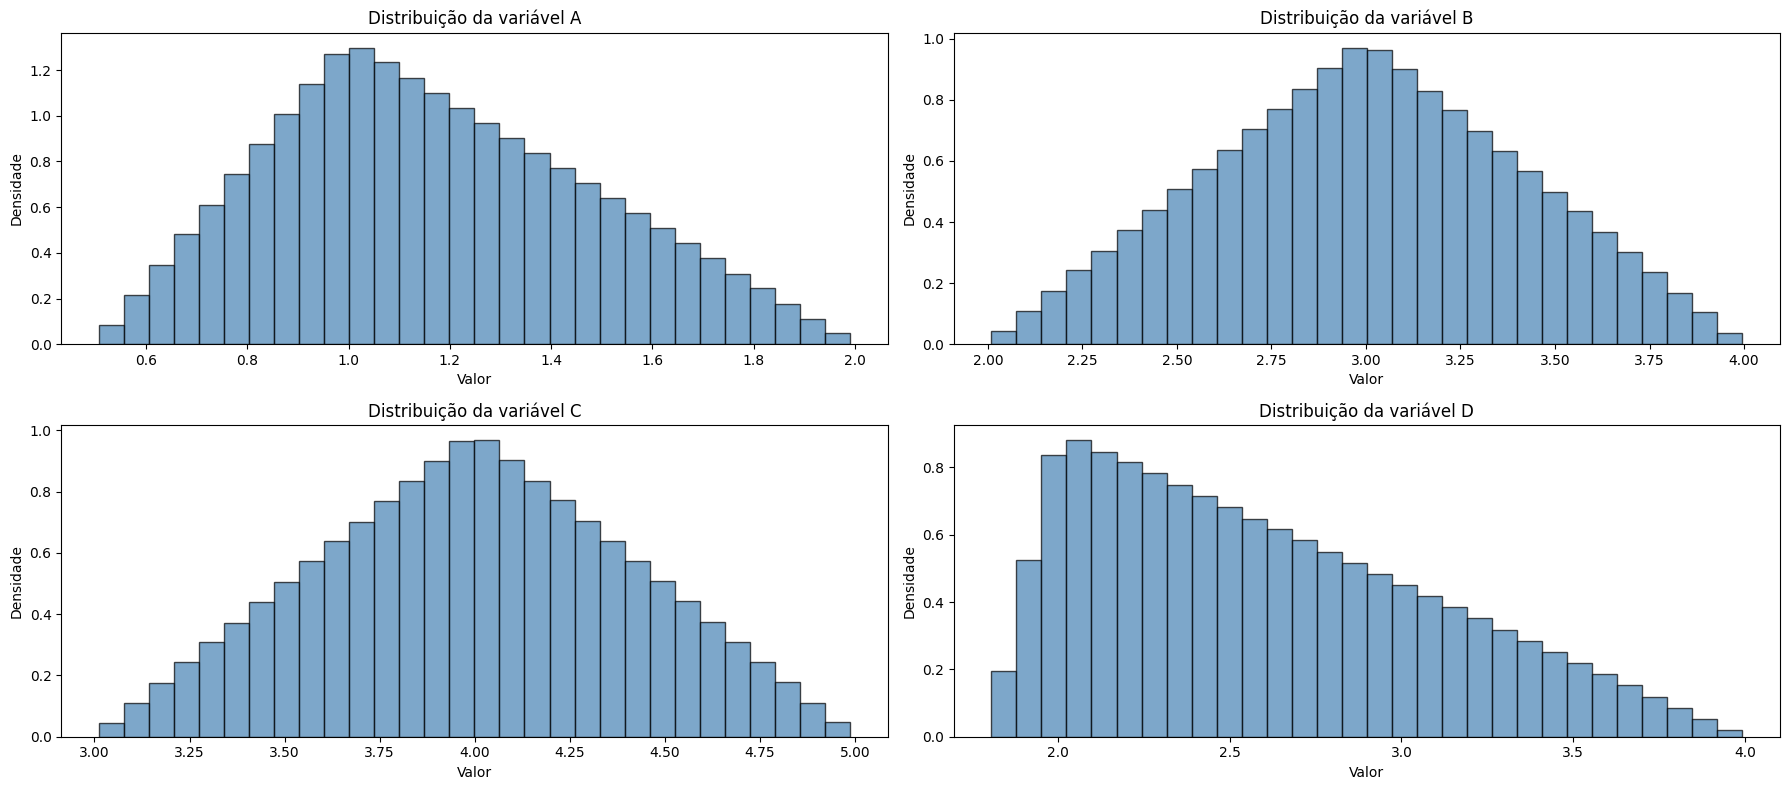

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(18, 8))
axs = axs.flatten()

for i, col in enumerate(amostras.columns):
    axs[i].hist(amostras[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black', density=True)
    axs[i].set_title(f'Distribuição da variável {col.upper()}')
    axs[i].set_xlabel('Valor')
    axs[i].set_ylabel('Densidade')

plt.tight_layout()
plt.show()


### Discretizar amostras

In [17]:
def discretizar_por_dias_inteiros(df_amostras):
    """
    Discretiza as amostras arredondando para o dia inteiro mais próximo.
    Os estados são os próprios dias. As probabilidades são suas frequências.
    """
    # 1. Arredonda todas as amostras para o inteiro mais próximo e converte para int
    df_arredondado = np.round(df_amostras).astype(int)
    
    parametros_discretizacao = {}
    print("\nDiscretizando por Dias Inteiros (arredondamento):")

    for atividade_codigo in df_arredondado.columns:
        counts = df_arredondado[atividade_codigo].value_counts(normalize=True).sort_index()

        estados = counts.index.tolist()
        probabilidades = counts.values.tolist()
     
        value_map = {estado: estado for estado in estados}
        
        parametros_discretizacao[atividade_codigo] = {
            'labels': estados,
            'value_map': value_map,
            'probs': probabilidades
        }
 
        print(f" - Task Name {atividade_codigo}: {len(estados)} estados -> {estados}")
        
    return parametros_discretizacao

In [18]:
params_discretizados = discretizar_por_dias_inteiros(amostras)
params_discretizados


Discretizando por Dias Inteiros (arredondamento):
 - Task Name A: 2 estados -> [1, 2]
 - Task Name B: 3 estados -> [2, 3, 4]
 - Task Name C: 3 estados -> [3, 4, 5]
 - Task Name D: 3 estados -> [2, 3, 4]


{'A': {'labels': [1, 2], 'value_map': {1: 1, 2: 2}, 'probs': [0.8333, 0.1667]},
 'B': {'labels': [2, 3, 4],
  'value_map': {2: 2, 3: 3, 4: 4},
  'probs': [0.125, 0.75, 0.125]},
 'C': {'labels': [3, 4, 5],
  'value_map': {3: 3, 4: 4, 5: 5},
  'probs': [0.125, 0.75, 0.125]},
 'D': {'labels': [2, 3, 4],
  'value_map': {2: 2, 3: 3, 4: 4},
  'probs': [0.4886, 0.4546, 0.0568]}}

### Construir rede bayaesiana

In [19]:

def criar_cpt_termino(model, codigo, num_termino_states, termino_labels, params_discretizacao):
    t_node = f"T_{codigo}"
    d_node = f"D_{codigo}"
    
    activity_params = params_discretizacao[codigo]
    duration_labels = activity_params['labels']
    num_duration_states = len(duration_labels)

    parents = sorted(list(model.predecessors(t_node)))
    
    evidence = parents
    evidence_card = []
    state_names = {t_node: termino_labels}
    
    t_parents = [p for p in parents if p.startswith('T_')]
    
    for parent in parents:
        if parent.startswith('T_'):
            evidence_card.append(num_termino_states)
            state_names[parent] = termino_labels
        else:
            parent_code = parent.split('_')[1]
            parent_labels = params_discretizacao[parent_code]['labels']
            evidence_card.append(len(parent_labels))
            state_names[parent] = parent_labels
            
    parent_state_combinations = itertools.product(*[range(card) for card in evidence_card])
    values = np.zeros((num_termino_states, np.prod(evidence_card)))
    
    for col_idx, combo in enumerate(parent_state_combinations):
        state_map = dict(zip(parents, combo))
        t_parent_states_indices = [state_map[p] for p in t_parents]
        max_of_t_parents = max(t_parent_states_indices) if t_parent_states_indices else -1
        
        d_state_index = state_map[d_node]
        d_state_value = params_discretizacao[codigo]['labels'][d_state_index] # Pega o valor real do dia
        
        # A lógica da soma agora usa valores de dias, não mais índices
        # Se T_A terminou na fase 5, e D_B dura 3 dias, T_B termina na fase 8
        result_state = min(max_of_t_parents + d_state_value, num_termino_states - 1)
        
        values[result_state, col_idx] = 1
        
    return TabularCPD(variable=t_node, variable_card=num_termino_states, values=values,
                      evidence=evidence, evidence_card=evidence_card, state_names=state_names)

In [22]:
def construir_rede_bayesiana_generica(df_projeto, params_discretizacao):
    G = nx.DiGraph()
    for _, row in df_projeto.iterrows():
        if pd.notna(row['Predecessors']):
            for pred in row['Predecessors'].split(','):
                G.add_edge(pred, row['Code'])
    
    # Estima o número de estados de término necessários (soma das durações máximas)
    max_duration_sum = 0
    if G.nodes:
        path = nx.dag_longest_path(G)
        max_duration_sum = sum(max(params['labels']) for code, params in params_discretizacao.items() if code in path)
    
    num_termino_states = max_duration_sum + 5
    termino_labels = list(range(num_termino_states)) 
    print(f"\nCriando {num_termino_states} estados de término (dias) para cobrir todas as possibilidades.\n")

    model = DiscreteBayesianNetwork()
    for _, row in df_projeto.iterrows():
        codigo = row['Code']
        model.add_edge(f"D_{codigo}", f"T_{codigo}")
        if pd.notna(row['Predecessors']):
            for pred in row['Predecessors'].split(','):
                model.add_edge(f"T_{pred}", f"T_{codigo}")

    all_cpds = []
    for _, row in df_projeto.iterrows():
        codigo = row['Code']
        params = params_discretizacao[codigo]
        d_node = f"D_{codigo}"
        prior_probs_array = np.array(params['probs']).reshape(len(params['labels']), 1)
        
        cpd_d = TabularCPD(variable=d_node, variable_card=len(params['labels']), 
                           values=prior_probs_array, state_names={d_node: params['labels']})
        all_cpds.append(cpd_d)
    
    # Adiciona as CPTs de Duração primeiro, para que a info esteja disponível
    model.add_cpds(*all_cpds)
    all_cpds = [] # Limpa a lista para adicionar as de término

    for _, row in df_projeto.iterrows():
        codigo = row['Code']
        cpd_t = criar_cpt_termino(model, codigo, num_termino_states, termino_labels, params_discretizacao)
        all_cpds.append(cpd_t)
        
    model.add_cpds(*all_cpds)

    print(f"Modelo Válido? {model.check_model()}\n")
    return model



### EXECUTAR

In [ ]:

bn_model = construir_rede_bayesiana_generica(df, params_discretizados)

# 4. Realizar Inferência
inference = VariableElimination(bn_model)

# Encontrar o nó final dinamicamente
G_final = nx.from_pandas_edgelist(df[df['Predecessors'].notna()].assign(Predecessors=lambda x: x.Predecessors.str.split(',')).explode('Predecessors'), 
                                    source='Predecessors', target='Code', create_using=nx.DiGraph)
final_node_code = [node for node in df['Code'] if G_final.out_degree(node, weight=None) == 0][0]
final_t_node = f"T_{final_node_code}"





Criando 15 estados de término (dias) para cobrir todas as possibilidades.

Modelo Válido? True



### Imprimir CPDs

In [38]:
for cpd in bn_model.get_cpds():
    print(cpd)
    print("-" * 80)


+--------+--------+
| D_A(1) | 0.8333 |
+--------+--------+
| D_A(2) | 0.1667 |
+--------+--------+
--------------------------------------------------------------------------------
+--------+-------+
| D_B(2) | 0.125 |
+--------+-------+
| D_B(3) | 0.75  |
+--------+-------+
| D_B(4) | 0.125 |
+--------+-------+
--------------------------------------------------------------------------------
+--------+-------+
| D_C(3) | 0.125 |
+--------+-------+
| D_C(4) | 0.75  |
+--------+-------+
| D_C(5) | 0.125 |
+--------+-------+
--------------------------------------------------------------------------------
+--------+--------+
| D_D(2) | 0.4886 |
+--------+--------+
| D_D(3) | 0.4546 |
+--------+--------+
| D_D(4) | 0.0568 |
+--------+--------+
--------------------------------------------------------------------------------
+---------+--------+--------+
| D_A     | D_A(1) | D_A(2) |
+---------+--------+--------+
| T_A(0)  | 1.0    | 0.0    |
+---------+--------+--------+
| T_A(1)  | 0.0    |

#### Calcular valor esperado

In [39]:
# --- Análise e Cálculo do Valor Esperado ---
def calcular_valor_esperado(query_result):
    """Calcula a média ponderada a partir do resultado de uma query da pgmpy."""
    valor_esperado = 0
    # CORREÇÃO: Pegamos o nome da variável da lista .variables
    variable_name = query_result.variables[0] 
    
    for i, prob in enumerate(query_result.values):
        # O estado é o próprio valor em dias
        valor_estado = query_result.state_names[variable_name][i]
        valor_esperado += prob * valor_estado
    return valor_esperado

#### Previsão sem inferencia

In [40]:

query_inicial = inference.query(variables=[final_t_node], show_progress=False)
duracao_esperada_inicial = calcular_valor_esperado(query_inicial)

print(f"--- Previsão Inicial para o Término do Projeto ({final_t_node}) ---")
print(query_inicial)
print(f"DURAÇÃO TOTAL ESPERADA INICIAL: {duracao_esperada_inicial:.2f} dias")




--- Previsão Inicial para o Término do Projeto (T_D) ---
+---------+------------+
| T_D     |   phi(T_D) |
+=========+============+
| T_D(0)  |     0.0000 |
+---------+------------+
| T_D(1)  |     0.0000 |
+---------+------------+
| T_D(2)  |     0.0000 |
+---------+------------+
| T_D(3)  |     0.0000 |
+---------+------------+
| T_D(4)  |     0.0000 |
+---------+------------+
| T_D(5)  |     0.0445 |
+---------+------------+
| T_D(6)  |     0.3621 |
+---------+------------+
| T_D(7)  |     0.4168 |
+---------+------------+
| T_D(8)  |     0.1528 |
+---------+------------+
| T_D(9)  |     0.0226 |
+---------+------------+
| T_D(10) |     0.0012 |
+---------+------------+
| T_D(11) |     0.0000 |
+---------+------------+
| T_D(12) |     0.0000 |
+---------+------------+
| T_D(13) |     0.0000 |
+---------+------------+
| T_D(14) |     0.0000 |
+---------+------------+
DURAÇÃO TOTAL ESPERADA INICIAL: 6.75 dias


#### Visualizar valores permitidos para cada atividade

In [30]:
def valores_permitidos(model, var):
    cpd = model.get_cpds(var)
    return cpd.state_names[var]

print("Valores permitidos para D_A:", valores_permitidos(bn_model, 'D_A'))
print("Valores permitidos para D_B:", valores_permitidos(bn_model, 'D_B'))
print("Valores permitidos para D_C:", valores_permitidos(bn_model, 'D_C'))
print("Valores permitidos para D_D:", valores_permitidos(bn_model, 'D_D'))


Valores permitidos para D_A: [1, 2]
Valores permitidos para D_B: [2, 3, 4]
Valores permitidos para D_C: [3, 4, 5]
Valores permitidos para D_D: [2, 3, 4]


#### Previsão com inferência

In [42]:

evidencia = {'D_A': 2, 'D_B': 4, 'D_C': 3}
query_atualizada = inference.query(variables=[final_t_node], evidence=evidencia, show_progress=True)
print(query_atualizada)
duracao_esperada_atualizada = calcular_valor_esperado(query_atualizada)

print(f"\n--- Previsão Atualizada (com evidência: {evidencia}) ---")
print(f"DURAÇÃO TOTAL ESPERADA ATUALIZADA: {duracao_esperada_atualizada:.2f} dias")

+---------+------------+
| T_D     |   phi(T_D) |
+=========+============+
| T_D(0)  |     0.0000 |
+---------+------------+
| T_D(1)  |     0.0000 |
+---------+------------+
| T_D(2)  |     0.0000 |
+---------+------------+
| T_D(3)  |     0.0000 |
+---------+------------+
| T_D(4)  |     0.0000 |
+---------+------------+
| T_D(5)  |     0.0000 |
+---------+------------+
| T_D(6)  |     0.0000 |
+---------+------------+
| T_D(7)  |     0.4886 |
+---------+------------+
| T_D(8)  |     0.4546 |
+---------+------------+
| T_D(9)  |     0.0568 |
+---------+------------+
| T_D(10) |     0.0000 |
+---------+------------+
| T_D(11) |     0.0000 |
+---------+------------+
| T_D(12) |     0.0000 |
+---------+------------+
| T_D(13) |     0.0000 |
+---------+------------+
| T_D(14) |     0.0000 |
+---------+------------+

--- Previsão Atualizada (com evidência: {'D_A': 2, 'D_B': 4, 'D_C': 3}) ---
DURAÇÃO TOTAL ESPERADA ATUALIZADA: 7.57 dias
